In [4]:
from datasets import load_dataset

dataset = load_dataset("roneneldan/TinyStoriesInstruct")

TinyStories-Instruct-train.txt: reconstructing file:   0%|          |  0.00B / 2.66GB            

TinyStories-Instruct-train.txt: downloading bytes:           |  0.00B            

TinyStories-Instruct-valid.txt: reconstructing file:   0%|          |  0.00B / 26.9MB            

TinyStories-Instruct-valid.txt: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/21755681 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/218380 [00:00<?, ? examples/s]

In [9]:
#  Check structure first
print(dataset)
print(dataset["train"].column_names)

# Full first example, raw
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 21755681
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 218380
    })
})
['text']
{'text': 'Features: Dialogue'}


In [10]:
sample = dataset["train"][0]["text"]
print(repr(sample))  # repr shows exact whitespace/delimiters

'Features: Dialogue'


In [11]:
for i in range(15):
    print(i, repr(dataset["train"][i]["text"]))

0 'Features: Dialogue'
1 'Words: quit, oak, gloomy'
2 'Summary: Sara and Ben were playing in the park, but Sara wanted to go home because it was cold and dark. Ben convinced her to stay and play, but eventually agreed to go home and have hot cocoa.'
3 'Story: '
4 ''
5 'Sara and Ben were playing in the park. They liked to climb the big oak tree and pretend they were birds. They made nests with leaves and twigs and sang songs.'
6 'But today, the sky was gloomy and the wind was cold. Sara felt sad and cold. She wanted to go home and have some hot cocoa.'
7 '"Ben, I want to quit," she said. "It\'s too cold and dark. Let\'s go home."'
8 'Ben looked at Sara and frowned. He liked the oak tree and the park. He wanted to stay and play.'
9 '"No, Sara, don\'t quit," he said. "It\'s fun here. Look, there\'s a squirrel. Let\'s chase it."'
10 "Sara shook her head. She didn't want to chase the squirrel. She wanted to go home and have some hot cocoa."
11 '"Please, Ben, let\'s go home," she said. "We c

In [12]:
def get_full_records(ds, n=1):
    records = []
    current = []
    for row in ds:
        text = row["text"]
        if text.strip() == "<|endoftext|>":
            records.append("\n".join(current))
            current = []
            if len(records) >= n:
                break
        else:
            current.append(text)
    return records

first_records = get_full_records(dataset["train"], n=1)
print(first_records[0])

Features: Dialogue
Words: quit, oak, gloomy
Summary: Sara and Ben were playing in the park, but Sara wanted to go home because it was cold and dark. Ben convinced her to stay and play, but eventually agreed to go home and have hot cocoa.
Story: 

Sara and Ben were playing in the park. They liked to climb the big oak tree and pretend they were birds. They made nests with leaves and twigs and sang songs.
But today, the sky was gloomy and the wind was cold. Sara felt sad and cold. She wanted to go home and have some hot cocoa.
"Ben, I want to quit," she said. "It's too cold and dark. Let's go home."
Ben looked at Sara and frowned. He liked the oak tree and the park. He wanted to stay and play.
"No, Sara, don't quit," he said. "It's fun here. Look, there's a squirrel. Let's chase it."
Sara shook her head. She didn't want to chase the squirrel. She wanted to go home and have some hot cocoa.
"Please, Ben, let's go home," she said. "We can play here another day. I'm cold and hungry."
Ben saw 

In [ ]:
# The extraction below uses multiprocessing.Pool, which needs a real __main__
# module to re-import in each spawned worker (macOS/Windows default to the
# "spawn" start method). A notebook kernel has no such file, so running the
# Pool code directly in a cell crashes with:
#   AttributeError: Can't get attribute 'worker' on <module '__main__' ...>
# Fix: the extraction now lives in extract_tinystories_instruct.py and runs
# as a subprocess instead.
!python extract_tinystories_instruct.py

In [20]:
import json

with open("/Users/omkarsatapaphy/python_works/Building_Language_models/Datasets/tinystories_instruct_train.jsonl") as f:
    for i, line in enumerate(f):
        if i == 2:
            print(json.loads(line))
            break

{'instruction': 'Write a story that includes the words mention, gun, strong, features dialogue, foreshadowing, and follows this summary: Two brothers, Tim and Sam, played pretend heroes with a toy gun until a real bad guy threatened them. Their neighbor, Mrs. Lee, saved them with a broom and called the police. They gave Mrs. Lee their toy gun and promised to never play with guns again.', 'story': 'Tim and Sam were brothers who liked to play pretend. They had a toy gun that made a loud noise when they pulled the trigger. They liked to pretend they were strong heroes who fought bad guys.\nOne day, they were playing in the backyard when they heard a knock on the door. It was their neighbor, Mrs. Lee, who was very old and kind. She brought them some cookies and asked them what they were playing.\n"We are strong heroes, Mrs. Lee," Tim said. "We have a gun and we can stop any bad guys."\n"That sounds like fun," Mrs. Lee said. "But be careful with that gun, boys. It might scare someone who do

In [22]:
# Word counting over 1M+ records is slow single-threaded; delegate to
# word_count_tinystories_instruct.py which parallelizes it across CPU cores
# via multiprocessing.Pool (must run as a script -- see its docstring).
!python word_count_tinystories_instruct.py

train: 1,071,263 stories -> /Users/omkarsatapaphy/python_works/Building_Language_models/Datasets/tinystories_instruct_train.jsonl
val: 10,741 stories -> /Users/omkarsatapaphy/python_works/Building_Language_models/Datasets/tinystories_instruct_val.jsonl
Saved word counts -> /Users/omkarsatapaphy/python_works/Building_Language_models/Datasets/tinystories_instruct_word_counts.npz


train: 1,071,263 stories
val:   10,741 stories


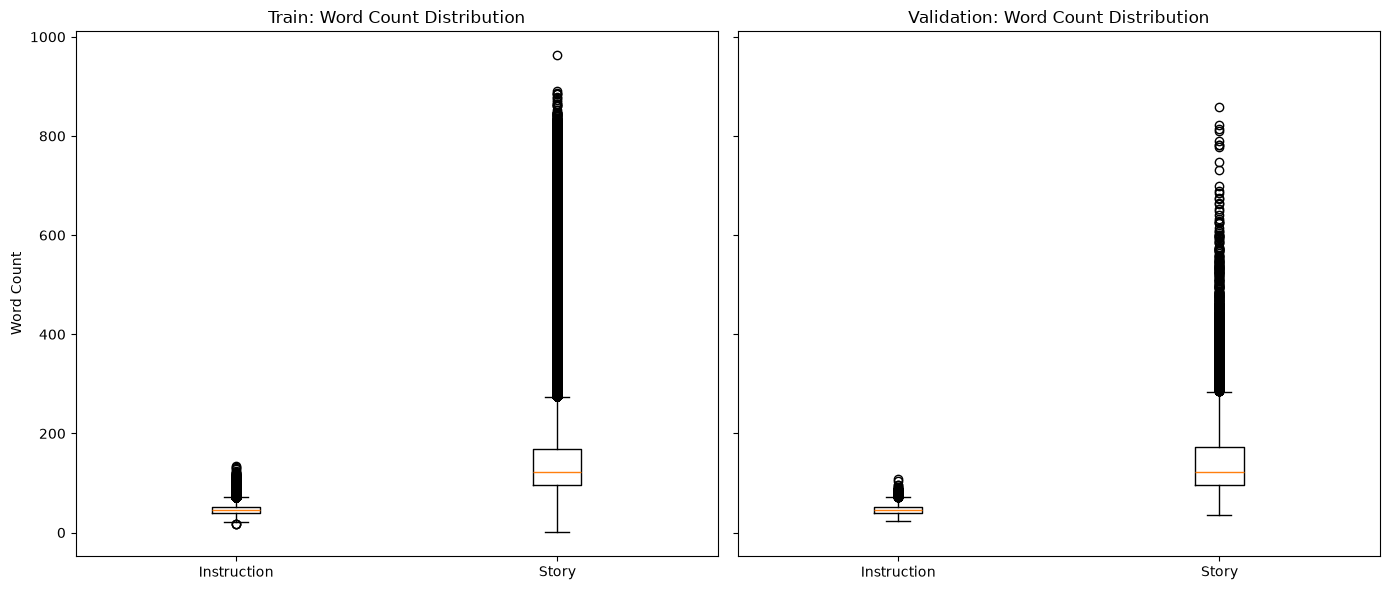

In [23]:
import numpy as np
import matplotlib.pyplot as plt

counts = np.load("/Users/omkarsatapaphy/python_works/Building_Language_models/Datasets/tinystories_instruct_word_counts.npz")
train_instruction_wc, train_story_wc = counts["train_instruction_wc"], counts["train_story_wc"]
val_instruction_wc, val_story_wc = counts["val_instruction_wc"], counts["val_story_wc"]

print(f"train: {len(train_instruction_wc):,} stories")
print(f"val:   {len(val_instruction_wc):,} stories")

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
axes[0].boxplot([train_instruction_wc, train_story_wc], tick_labels=["Instruction", "Story"])
axes[0].set_title("Train: Word Count Distribution")
axes[0].set_ylabel("Word Count")

axes[1].boxplot([val_instruction_wc, val_story_wc], tick_labels=["Instruction", "Story"])
axes[1].set_title("Validation: Word Count Distribution")

plt.tight_layout()
plt.show()

In [ ]:
# Flatten both JSONL splits into one .txt each, wrapping every field in its own
# special token:
#   <|startofinstruction|>...<|endofinstruction|><|startofstory|>...<|endofstory|>
# Stories are escaped to a single line ("\n" stays literal) so one record = one
# line; pass --keep-newlines to keep the original line breaks instead.
# Parallelized across all cores with multiprocessing.Pool, so it runs as a
# script rather than in-cell -- see extract_tinystories_instruct.py's docstring.
!python build_tinystories_instruct_txt.py